## **`RNN Implementation for Time-Series Forecasting`**

**Dataset loading**

In [5]:
import tensorflow as tf
import pandas as pd

url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

df = pd.read_csv(url, compression='zip')

print(df.head())
print("\n")
print(df.columns)
print("\n")
print(df.shape)
print("\n")

target = df['T (degC)']

features = df.drop(columns=['Date Time', 'T (degC)'])

data = pd.concat([features, target], axis=1)

print("Features shape:", features.shape)
print("Target shape:", target.shape)

             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03        

**Data Preprocessing**

In [7]:
import pandas as pd

# Convert to datetime
df['Date Time'] = pd.to_datetime(df['Date Time'], dayfirst=True)

# Extract features
df['hour'] = df['Date Time'].dt.hour
df['day'] = df['Date Time'].dt.day
df['month'] = df['Date Time'].dt.month

# Drop original timestamp column
df = df.drop(columns=['Date Time'])

# Target variable
target_col = df.columns.get_loc('T (degC)')

# Convert dataframe to numpy array
data = df.values

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

import numpy as np

def create_sequences(data, target_col, time_steps=24):
    sequences = []
    labels = []

    for i in range(len(data) - time_steps):
        sequences.append(data[i:i + time_steps])
        labels.append(data[i + time_steps, target_col])

    return np.array(sequences), np.array(labels)

time_steps = 24

X, y = create_sequences(data_scaled, target_col, time_steps)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (420527, 24, 17)
Output shape: (420527,)


**Model Construction**

1. Import Required Layers

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input


2. Build the RNN Model

In [10]:
model = Sequential()

# Input Layer (recommended way)
model.add(Input(shape=(X.shape[1], X.shape[2])))

# RNN Layer 1
model.add(SimpleRNN(64, return_sequences=True))
model.add(Dropout(0.2))

# RNN Layer 2
model.add(SimpleRNN(32))
model.add(Dropout(0.2))

# Dense Output Layer
model.add(Dense(1))

3. Compile the Model

In [11]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 24, 64)         │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,385 (32.75 KB)

 Trainable params: 8,385 (32.75 KB)

 Non-trainable params: 0 (0.00 B)

**Model Training and Testing**

1. Split Dataset (80% Training, 20% Testing)

In [12]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

2. Compile the Model

In [13]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

3. Train Model (20 Epochs)

In [14]:
history_20 = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 94s 9ms/step - loss: 0.0047 - val_loss: 1.0453e-04
Epoch 2/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 139s 8ms/step - loss: 2.8205e-04 - val_loss: 1.0351e-04
Epoch 3/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 146s 9ms/step - loss: 2.5798e-04 - val_loss: 2.2813e-05
Epoch 4/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 145s 9ms/step - loss: 3.1850e-04 - val_loss: 4.9474e-05
Epoch 5/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 136s 9ms/step - loss: 2.4809e-04 - val_loss: 5.7511e-05
Epoch 6/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 95s 9ms/step - loss: 2.5275e-04 - val_loss: 4.5668e-05
Epoch 7/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 134s 8ms/step - loss: 2.4542e-04 - val_loss: 2.8033e-05
Epoch 8/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 141s 8ms/step - loss: 2.4347e-04 - val_loss: 3.5587e-05
Epoch 9/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 86s 8ms/step - loss: 2.4665e-04 - val_loss: 3.6428e-05
Epoch 10/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 90s 9ms/step - loss: 2.3995e-04 - val_loss: 3.4774e-05
Epoch 1

4. Train Model (50 Epochs)

In [15]:
# Rebuild model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input

model_50 = Sequential()
model_50.add(Input(shape=(X.shape[1], X.shape[2])))
model_50.add(SimpleRNN(64, return_sequences=True))
model_50.add(Dropout(0.2))
model_50.add(SimpleRNN(32))
model_50.add(Dropout(0.2))
model_50.add(Dense(1))

model_50.compile(optimizer='adam', loss='mean_squared_error')

history_50 = model_50.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32
)

Epoch 1/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 98s 9ms/step - loss: 0.0038 - val_loss: 6.6239e-05
Epoch 2/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 94s 9ms/step - loss: 2.7789e-04 - val_loss: 1.0827e-04
Epoch 3/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 88s 8ms/step - loss: 2.5342e-04 - val_loss: 3.7440e-05
Epoch 4/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 140s 8ms/step - loss: 2.4738e-04 - val_loss: 3.9695e-05
Epoch 5/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 88s 8ms/step - loss: 2.4264e-04 - val_loss: 7.6481e-05
Epoch 6/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 84s 8ms/step - loss: 2.4212e-04 - val_loss: 5.5083e-05
Epoch 7/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 85s 8ms/step - loss: 2.3911e-04 - val_loss: 1.1524e-04
Epoch 8/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 84s 8ms/step - loss: 2.4018e-04 - val_loss: 1.3916e-04
Epoch 9/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 85s 8ms/step - loss: 2.3959e-04 - val_loss: 3.7350e-05
Epoch 10/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 142s 8ms/step - loss: 2.3521e-04 - val_loss: 2.7802e-05
Epoch 11/50

5. Evaluate Model Performance

In [16]:
loss_20 = model.evaluate(X_test, y_test)
loss_50 = model_50.evaluate(X_test, y_test)

print("Test Loss (20 epochs):", loss_20)
print("Test Loss (50 epochs):", loss_50)

2629/2629 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.1492e-04
2629/2629 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 8.8390e-05
Test Loss (20 epochs): 0.00011491700570331886
Test Loss (50 epochs): 8.839021757012233e-05


6. Plot Training vs Validation Loss

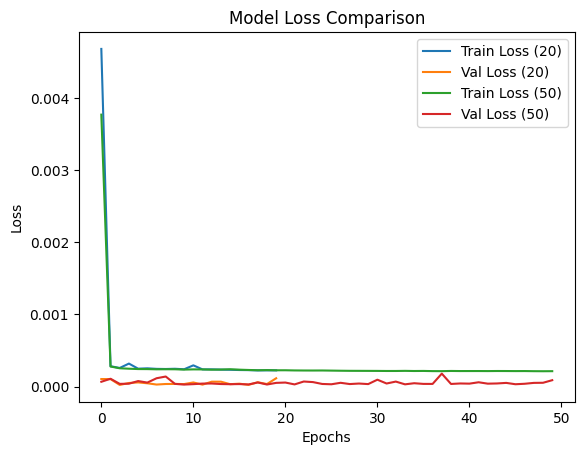

In [17]:
import matplotlib.pyplot as plt

plt.plot(history_20.history['loss'], label='Train Loss (20)')
plt.plot(history_20.history['val_loss'], label='Val Loss (20)')

plt.plot(history_50.history['loss'], label='Train Loss (50)')
plt.plot(history_50.history['val_loss'], label='Val Loss (50)')

plt.legend()
plt.title("Model Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

**Model Saving**

1. Save Model (Keras)

In [20]:
model.save('rnn_time_series.keras')

2. Load Saved Model (Keras)

In [24]:
load_model('rnn_time_series.keras')

loaded_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

**Model Evaluation**

**1. Make Predictions**

In [25]:
predictions = model.predict(X_test)

2629/2629 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


2. Convert Back to Original Scale

In [26]:
# Reshape for inverse scaling
predictions = scaler.inverse_transform(
    np.concatenate((np.zeros((len(predictions), data.shape[1]-1)), predictions), axis=1)
)[:, -1]

y_test_actual = scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), data.shape[1]-1)), y_test.reshape(-1,1)), axis=1)
)[:, -1]

3. Compute Performance Metrics

In [27]:
# Mean Absolute Error (MAE)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test_actual, predictions)
print("MAE:", mae)

# Root Mean Squared Error (RMSE)
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("RMSE:", rmse)



MAE: 0.09537913160788891
RMSE: 0.1179192930685192


4. Plot Actual vs Predicted Values

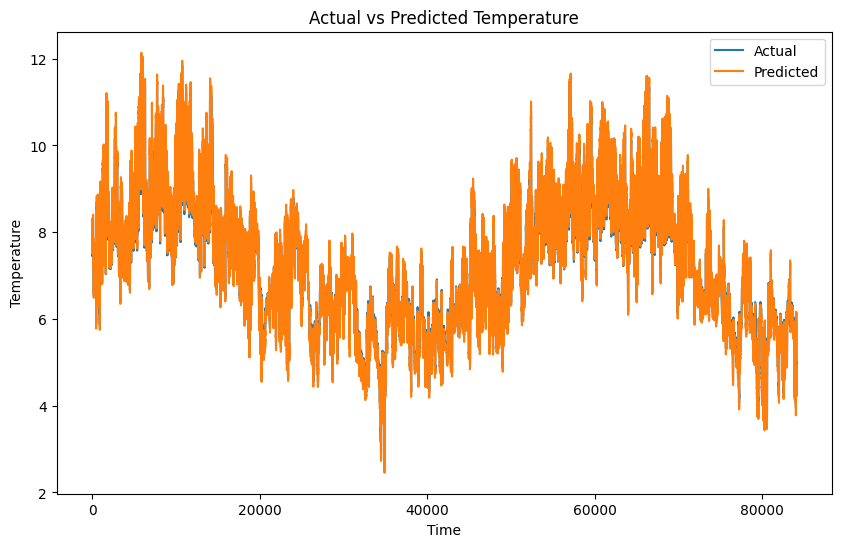

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()

plt.show()

**Loss Comparison (20 vs 50 epochs)**

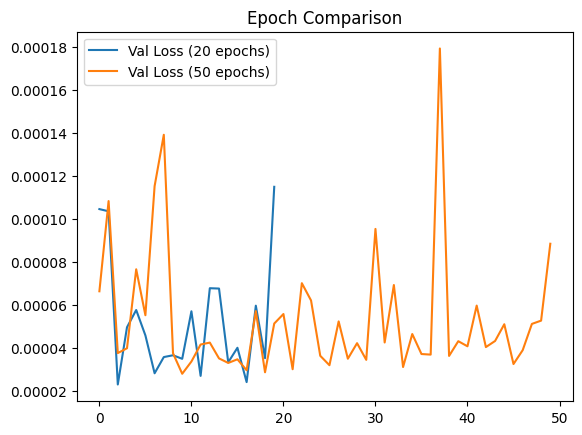

In [29]:
plt.plot(history_20.history['val_loss'], label='Val Loss (20 epochs)')
plt.plot(history_50.history['val_loss'], label='Val Loss (50 epochs)')
plt.legend()
plt.title("Epoch Comparison")
plt.show()